# Fase 3: Evaluación del dataset generado

**Objetivo de esta fase**: evaluar cuantitativamente la calidad del dataset sintético generado en la fase anterior y comparar el rendimiento de las distintas técnicas de prompting (columna `technique`) bajo un conjunto fijo de métricas.

**Criterios evaluados en este notebook**:
Se analiza el dataset resultante desde tres dimensiones fundamentales:

1. Calidad lingüística: medida a través de Perplexity (PPL) con un modelo base externo de referencia (independiente del modelo generador) para reducir sesgos de autoevaluación.
2. Relevancia y adecuación a las instrucciones: memedias a través de
    - comprobaciones simbólicas de las condiciones explícitas:
        - Longitud esperada (90–130 palabras).
        - Formato: un párrafo, sin listas.
        - Prohibición de menciones a IA/LLMs y “meta-lenguaje” de asistente.
        - Inclusión de variables de contexto (p.ej., `product`).
        - Consistencia rating ↔ sentimiento.
        - Coherencia semántica con `topic`.
    - una métrica de similitud semántica basada en embeddings: BERTScore para capturar adecuación semántica más allá de coincidencias léxicas.
3. Diversidad: medida a través de
    - Distinct-n, para la diversidad léxica (proporción de n-gramas únicos).
    - Self-BLEU, para la redundancia interna (valores altos implican menor diversidad).
    - TTR (Type-Token Ratio), para la diversidad de vocabulario (métrica sensible a longitud).

**Salidas generadas**:
  - `results_ppl_per_review.xlsx`: PPL por reseña.
  - `results_ppl_by_technique.xlsx`: PPL agregada por técnica.
  - `results_prompt_compliance_per_review.xlsx`: cumplimiento por reseña.
  - `results_prompt_compliance_by_technique.xlsx`: cumplimiento agregado por técnica.
  - `results_bertscore_per_review.xlsx`: BERTScore por reseña.
  - `results_bertscore_by_technique.xlsx`: BERTScore agregado por técnica.
  - `results_distinct_n_by_technique.xlsx`: Distinct-1/2 por técnica.
  - `results_self_bleu_by_technique.xlsx`: Self-BLEU por técnica.
  - `results_ttr_by_technique.xlsx`: TTR por técnica.


## Paso 1: Instalación de librerías

En esta fase se usa:

- `bert-score` para medir la similitud semántica (BERTScore) entre cada reseña y una referencia derivada del prompt.
- `transformers`, `sentencepiece`, `accelerate` para cargar modelos preentrenados (tokenizer + LM de referencia) y ejecutar inferencia de forma eficiente.
- `pandas`, `numpy` para lectura, limpieza y agregación de resultados por reseña y por técnica (technique).
- `torch` para ejecutar los modelos y calcular pérdidas (necesario para Perplexity).
- `nltk` para utilidades de tokenización y cálculo de métricas basadas en n-gramas (p. ej., Self-BLEU).
- `matplotlib` para visualizaciones exploratorias (si se incluyen gráficos).
- `re`, `unicodedata` para normalización y validaciones del cumplimiento del prompt (restricciones simbólicas).


In [ ]:
# Instala BERTScore para evaluar adecuación semántica basada en embeddings.
!pip install bert-score

# Instala librerías del ecosistema Hugging Face para cargar modelos/tokenizers y acelerar inferencia.
!pip -q install transformers sentencepiece accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 6.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import math
import torch

# Transformers: carga de modelos/tokenizers y utilidades de pipeline
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

import matplotlib.pyplot as plt
import re
import unicodedata
import torch.nn.functional as F

# BERTScore: función principal para calcular precision/recall/F1 semántico.
from bert_score import score

from collections import Counter

# NLTK: Self-BLEU y smoothing para BLEU a nivel de oración.
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import nltk

# Descarga recursos necesarios para tokenización (puntk).
nltk.download("punkt")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

## Paso 2: Carga del dataset generado

En esta fase se:

1. **Carga** y **visualiza** el dataset sintético desde Excel (`dataset.xlsx`) en un DataFrame (`df`).
2. **Carga** un modelo de lenguaje multilingüe de referencia (BSC-LT/salamandra-2b) para métricas posteriores (especialmente Perplexity), garantizando un vocabulario adecuado para textos en español.
3. **Analiza** la distribución de longitud en tokens del corpus para detectar reseñas fuera de las restricciones de longitud y localizar qué técnicas (`technique`) las generan con más frecuencia.

In [ ]:
# Importamos el dataset y mostramos su contenido
df = pd.read_excel('dataset.xlsx')
df

,technique,condition_id,product,persona,rating,tone,topic,prompt,text,attempts
0,few_shot,Cafetera italiana|persona que prepara café en ...,Cafetera italiana,persona que prepara café en casa a diario,5,cercano,NaN,"Escribe una reseña textual realista, similar a...",Mi querida Pat tiene una de las GRANDES voces ...,1
1,few_shot,Cafetera italiana|persona que prepara café en ...,Cafetera italiana,persona que prepara café en casa a diario,5,cercano,NaN,"Escribe una reseña textual realista, similar a...",He tenido esta cafetera italiana durante vario...,1
2,few_shot,Cafetera italiana|persona que prepara café en ...,Cafetera italiana,persona que prepara café en casa a diario,5,cercano,NaN,"Escribe una reseña textual realista, similar a...",Me compré esta cafetera italiana hace unos dos...,1
3,few_shot,Cafetera italiana|persona que prepara café en ...,Cafetera italiana,persona que prepara café en casa a diario,5,cercano,NaN,"Escribe una reseña textual realista, similar a...",Me compré esta cafetera italiana hace unos mes...,1
4,few_shot,Cafetera italiana|persona que prepara café en ...,Cafetera italiana,persona que prepara café en casa a diario,5,cercano,NaN,"Escribe una reseña textual realista, similar a...","Me encanta esta cafetera italiana, he tenido l...",1
...,...,...,...,...,...,...,...,...,...,...
845,automatic_prompt_engineering,Soporte para portátil|teletrabajador|5|formal,Soporte para portátil,teletrabajador,5,formal,experiencia de compra,Escribe una reseña informativa y objetiva sobr...,He tenido la oportunidad de probar el soporte ...,10
846,automatic_prompt_engineering,Soporte para portátil|teletrabajador|5|formal,Soporte para portátil,teletrabajador,5,formal,comodidad,Genera una reseña de un producto de negocio lo...,Me gustaría compartir mi experiencia con el so...,10
847,automatic_prompt_engineering,Soporte para portátil|teletrabajador|5|formal,Soporte para portátil,teletrabajador,5,formal,valor aportado en el contexto personal,Comparte tus impresiones y experiencias con un...,Me encanta el soporte para portátil que compré...,10
848,automatic_prompt_engineering,Soporte para portátil|teletrabajador|5|formal,Soporte para portátil,teletrabajador,5,formal,primeras impresiones frente a experiencia real,Escriba una reseña detallada sobre un producto...,Me sorprendió positivamente el soporte para po...,10


Para usar algunas métricas vamos a necesitar un modelo base con vocabulario o en español o multilingüístico. En este caso se usa un modelo del **Language Technologies Laboratory @ Barcelona Supercomputing Center**, en concreto un modelo de generación de texto pequeño multilingüístico:
[BSC-LT/salamandra-2b](https://huggingface.co/BSC-LT/salamandra-2b)



In [ ]:
MODEL_NAME = "BSC-LT/salamandra-2b"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    device_map="auto", # permite usar GPU si está disponible
    dtype=torch.float16 # dtype=float16 reduce memoria
)

model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/678 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/989 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/37.0M [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/4.81M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/4.51G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/219 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(256000, 2048)
    (layers): ModuleList(
      (0-23): 24 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (v_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=5440, bias=False)
          (up_proj): Linear(in_features=2048, out_features=5440, bias=False)
          (down_proj): Linear(in_features=5440, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((2048,), eps=1e-05)
    (

Estadísticas de longitud en tokens
n_texts: 850
min_tokens: 23
max_tokens: 189
mean_tokens: 137.3329411764706
median_tokens: 137.0
p90_tokens: 157.0
p95_tokens: 162.0
p99_tokens: 173.52999999999997


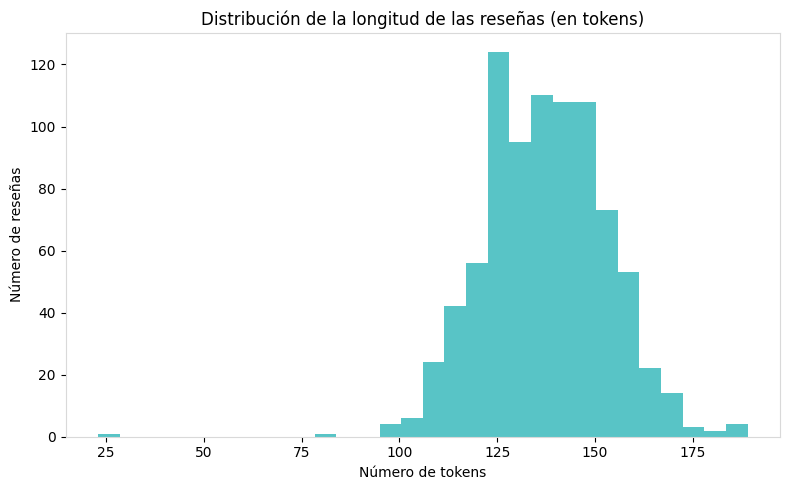

In [ ]:
def token_length_stats(texts):
  """
  Calcula la longitud en tokens de las reseñas generadas.
  """
    lengths = []
    for t in texts:
        ids = tokenizer(t, truncation=False)["input_ids"]
        lengths.append(len(ids))
    lengths = np.array(lengths)

    stats = {
        "n_texts": len(lengths),
        "min_tokens": int(lengths.min()),
        "max_tokens": int(lengths.max()),
        "mean_tokens": float(lengths.mean()),
        "median_tokens": float(np.median(lengths)),
        "p90_tokens": float(np.percentile(lengths, 90)),
        "p95_tokens": float(np.percentile(lengths, 95)),
        "p99_tokens": float(np.percentile(lengths, 99)),
    }
    return stats, lengths

stats, lengths = token_length_stats(df["text"].tolist())

print("Estadísticas de longitud en tokens")
for k, v in stats.items():
    print(f"{k}: {v}")

# Visualización de la distribución de longitudes en tokens
plt.figure(figsize=(8, 5))
plt.hist(lengths, bins=30, color="#58c4c6")

ax = plt.gca()

for spine in ax.spines.values():
    spine.set_color("#d9d9d9")

# Ticks y números en blanco
ax.tick_params(colors="#000000")
ax.xaxis.label.set_color("#000000")
ax.yaxis.label.set_color("#000000")
ax.title.set_color("#d9d9d9")

plt.xlabel("Número de tokens")
plt.ylabel("Número de reseñas")
plt.title("Distribución de la longitud de las reseñas (en tokens)", color = "#000000")
plt.tight_layout()
plt.show()

In [ ]:
# Asociamos la técnica empleada a las reseñas cortas generadas.

# 1) Asociar número de tokens al DataFrame
df["n_tokens"] = lengths

# 2) Filtrar reseñas cortas (< 90 tokens)
short_df = df[df["n_tokens"] < 90]
print(f"Número total de reseñas con menos de 90 tokens: {len(short_df)}\n")

# 3) Conteo por técnica
short_by_technique = (
    short_df.groupby("technique")
            .size()
            .reset_index(name="n_short_reviews")
            .sort_values("n_short_reviews", ascending=False)
)

display(short_by_technique)

# 4) Porcentaje dentro de cada técnica
total_by_technique = (
    df.groupby("technique")
      .size()
      .reset_index(name="n_total_reviews")
)

short_ratio = short_by_technique.merge(
    total_by_technique,
    on="technique",
    how="left"
)

short_ratio["percentage_short"] = (
    short_ratio["n_short_reviews"] / short_ratio["n_total_reviews"] * 100
).round(2)

display(short_ratio.sort_values("percentage_short", ascending=False))

## Paso 3: Evaluación de calidad del dataset

En esta fase se implementan las métricas definidas previamente para evaluar el dataset sintético generado.

El análisis se organiza en tres bloques:
1. Calidad lingüística, mediante el cálculo de Perplexity (PPL) con un modelo de referencia externo.
2. Relevancia y adecuación a las instrucciones, combinando verificaciones automáticas de las restricciones del prompt y el cálculo de BERTScore.
3. Diversidad, a través de métricas que cuantifican variedad léxica y redundancia interna del corpus: Distinct-n, Self-BLEU y TTR (Type-Token Ratio)

Las métricas se calculan tanto a nivel individual (por reseña) como de forma agregada por técnica (technique), lo que permite comparar sistemáticamente el comportamiento de las distintas estrategias de prompting.

### **A) Calidad lingüística**

Se calcula *Perplexity (PPL)* por reseña utilizando un modelo base externo en GPU.

- Perplexity = exp(pérdida media por token)
- Valores más bajos indican mayor fluidez y naturalidad según el modelo de referencia.

Posteriormente, la PPL se resume por técnica (`technique`) mediante estadísticos descriptivos y se calculan los whiskers según el criterio de Tukey (1.5 × IQR) para detectar valores atípicos.

In [ ]:
# Modelo base: "BSC-LT/salamandra-2b" en GPU

# Asegurar PAD token
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
model.config.pad_token_id = tokenizer.pad_token_id

# Perplexity en GPU
@torch.no_grad()
def compute_perplexity(text: str) -> float:
    if not text:
        return float("nan")
    enc = tokenizer(
        text,
        return_tensors="pt",
        truncation=True
    )

    enc = {k: v.to(model.device) for k, v in enc.items()}
    outputs = model(
        enc["input_ids"],
        labels=enc["input_ids"]
    )
    loss = outputs.loss.item()
    return math.exp(loss)

# Calcular PPL por reseña
df["ppl"] = [compute_perplexity(t) for t in df["text"]]

# Resumen por técnica
summary_ppl = (
    df.groupby("technique", dropna=False)["ppl"]
      .agg(
          n="count",
          mean="mean",
          std="std",
          median="median",
          q1=lambda s: s.quantile(0.25),
          q3=lambda s: s.quantile(0.75),
          min="min",
          max="max"
      )
      .reset_index()
)

# Añadir IQR y whiskers (Tukey: 1.5*IQR)
summary_ppl["iqr"] = summary_ppl["q3"] - summary_ppl["q1"]
summary_ppl["lower_fence"] = summary_ppl["q1"] - 1.5 * summary_ppl["iqr"]
summary_ppl["upper_fence"] = summary_ppl["q3"] + 1.5 * summary_ppl["iqr"]

# Whiskers reales (recortados a valores existentes del grupo)
# Nota: no es el "min/max", sino el mínimo/máximo dentro de las fences
whiskers = (
    df.merge(summary_ppl[["technique", "lower_fence", "upper_fence"]], on="technique", how="left")
      .assign(in_fence=lambda x: (x["ppl"] >= x["lower_fence"]) & (x["ppl"] <= x["upper_fence"]))
      .groupby("technique", dropna=False)
      .apply(lambda g: pd.Series({
          "whislo": g.loc[g["in_fence"], "ppl"].min(),
          "whishi": g.loc[g["in_fence"], "ppl"].max(),
          "outliers_n": int((~g["in_fence"]).sum())
      }))
      .reset_index()
)

summary_ppl = summary_ppl.merge(whiskers, on="technique", how="left")

# Orden por media
summary_ppl = summary_ppl.sort_values("mean", ascending=True)

display(summary_ppl)

# Guardar resultados
df.to_excel("results_ppl_per_review.xlsx", index=False)
summary_ppl.to_excel("results_ppl_by_technique.xlsx", index=False)

/tmp/ipython-input-3249454379.py:59: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,technique,n,mean,std,median,q1,q3,min,max,iqr,lower_fence,upper_fence,whislo,whishi,outliers_n
3,instruction_based,100,7.097540,1.650464,6.831012,6.040813,8.015710,4.070342,12.031326,1.974897,3.078467,10.978056,4.070342,10.660661,2.0
5,one_shot,100,7.286531,1.527370,6.997235,6.024767,8.315299,4.445328,11.472973,2.290532,2.588968,11.751097,4.445328,11.472973,0.0
0,automatic_prompt_engineering,50,7.351158,1.406053,7.165778,6.541301,8.093393,4.788489,13.309234,1.552092,4.213163,10.421531,4.788489,10.054263,1.0
9,zero_shot_topic_generation,100,7.450978,1.975745,7.071759,6.044766,8.302272,4.265520,15.839483,2.257506,2.658506,11.688532,4.265520,10.980655,4.0
8,zero_shot,100,7.489656,1.607960,7.224398,6.512762,8.327994,4.965231,12.848063,1.815232,3.789913,11.050842,4.965231,10.630276,5.0
7,topic_controlled,100,7.594127,1.732515,7.273238,6.186401,8.521125,4.688533,12.662674,2.334725,2.684313,12.023213,4.688533,11.861910,2.0
2,few_shot,100,7.741777,2.016113,7.326058,6.359607,8.686049,4.195664,17.013319,2.326443,2.869943,12.175714,4.195664,11.781973,4.0
6,randomized,100,7.769505,1.573115,7.556880,6.614522,8.730765,4.748062,13.172398,2.116242,3.440159,11.905128,4.748062,11.276720,2.0
1,feedback_driven_prompting,50,7.886984,1.710219,7.702736,6.899982,8.654673,4.886973,12.732794,1.754691,4.267946,11.286709,4.886973,10.533881,3.0
4,iterative_prompting,50,8.480006,1.906207,8.193269,7.116102,9.260890,5.164949,13.388838,2.144788,3.898920,12.478072,5.164949,12.061086,2.0


### **B) Relevancia y adecuación al prompt**

Se calcula un **índice de cumplimiento** (compliance) por reseña combinando comprobaciones automáticas del formato/contenido y verificaciones semánticas (sentimiento, tono y topic).

Cada condición devuelve True/False y el cumplimiento global se obtiene como el promedio de las condiciones aplicables.

Finalmente, se resume el cumplimiento por técnica (`technique`) y se exportan los resultados.

In [ ]:
# Comprobación cumplimiento condiciones del prompt

# cumplimiento de las condiciones en def constraints_block():
  # - Longitud: 90 - 130 palabras.
  # - Contenido: Incluye detalles concretos sobre la experiencia de uso.
  # - Estilo: natural y humano, propio de un cliente real.
  # - Formato: un único párrafo, sin listas ni numeración.
  # - Prohibido: mencionar modelos de lenguaje, IA o sistemas automáticos.
  # - Salida: devuelve únicamente el texto final de la reseña.

# producto | perfil del cliente | valoración | tono
# tema cuando se indica

# =========================================================================

# Modelos
SENT_MODEL = "finiteautomata/beto-sentiment-analysis"
ZS_MODEL = "joeddav/xlm-roberta-large-xnli"
EMB_MODEL = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"

# Configuración básica
MIN_WORDS = 90
MAX_WORDS = 130
MIN_SENT_CONF = 0.50
TOPIC_SIM_THRESHOLD = 0.35

def normalize_text(s: str) -> str:
    s = s.lower().strip()
    s = unicodedata.normalize("NFKD", s)
    s = "".join(c for c in s if not unicodedata.combining(c))
    s = re.sub(r"\s+", " ", s)
    return s

def word_count(s: str) -> int:
    return len(re.findall(r"\b\w+\b", s, flags=re.UNICODE))

# Checks automáticos
BANNED_RE = re.compile(
    r"\b(chatgpt|llm|modelo(s)? de lenguaje|inteligencia artificial|ia|"
    r"sistema(s)? automatico(s)?|automaticamente|openai|gpt)\b",
    flags=re.IGNORECASE
)

META_RE = re.compile(
    r"\b(a continuacion|aquí tienes|aqui tienes|esta es.*reseña|"
    r"reseña:|review:|texto final|como modelo)\b",
    flags=re.IGNORECASE
)

LIST_RE = re.compile(r"(^|\n)\s*(?:[-•*]|\d+[\.\)])\s+", flags=re.MULTILINE)

def check_length(text):
    wc = word_count(text)
    return MIN_WORDS <= wc <= MAX_WORDS

def check_single_paragraph(text):
    return "\n" not in text.strip()

def check_no_lists(text):
    return LIST_RE.search(text) is None

def check_no_banned(text):
    return BANNED_RE.search(text) is None

def check_no_meta(text):
    return META_RE.search(text) is None

def check_contains(text, value):
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return True
    value = str(value).strip()
    if not value:
        return True
    return normalize_text(value) in normalize_text(text)

# Sentiment Analysis
device = 0 if torch.cuda.is_available() else -1

sent_pipe = pipeline(
    "text-classification",
    model=SENT_MODEL,
    tokenizer=SENT_MODEL,
    device=device,
    truncation=True
)

BATCH_SIZE = 32 if device == 0 else 8
sent_outputs = []

for i in range(0, len(df), BATCH_SIZE):
    batch = df["text"].iloc[i:i+BATCH_SIZE].tolist()
    sent_outputs.extend(sent_pipe(batch))

def label_to_polarity(label):
    l = label.lower()
    if "pos" in l: return "positive"
    if "neg" in l: return "negative"
    if "neu" in l: return "neutral"
    return "unknown"

df["sent_label"] = [o["label"] for o in sent_outputs]
df["sent_score"] = [float(o["score"]) for o in sent_outputs]
df["sent_polarity"] = [label_to_polarity(l) for l in df["sent_label"]]

# Rating
def rating_to_expected_polarity(r, r_min, r_max):
    if np.isnan(r): return "unknown"
    if r_max <= 5:
        return "negative" if r <= 2 else "neutral" if r == 3 else "positive"
    return "negative" if r <= 4 else "neutral" if r <= 6 else "positive"

if "rating" in df.columns:
    df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
    r_min, r_max = df["rating"].min(), df["rating"].max()
else:
    r_min = r_max = np.nan

def check_rating_sentiment(row):
    if "rating" not in df.columns or np.isnan(row["rating"]):
        return True
    if row["sent_score"] < MIN_SENT_CONF:
        return False
    expected = rating_to_expected_polarity(row["rating"], r_min, r_max)
    return row["sent_polarity"] == expected

# Tono
tone_vals = set(df["tone"].dropna().astype(str).map(normalize_text))
polarity_markers = ["positivo","positiva","negative","negativo","neutral","neutro","pos","neg","neu"]

tone_is_polarity = False
print(f"TONE IS POLARITY: {tone_is_polarity}")

if tone_is_polarity:
    def tone_to_polarity(t):
        t = normalize_text(t)
        if "pos" in t: return "positive"
        if "neg" in t: return "negative"
        if "neu" in t: return "neutral"
        return "unknown"

    def check_tone(row):
        target = tone_to_polarity(row["tone"])
        if target == "unknown" or row["sent_score"] < MIN_SENT_CONF:
            return False
        return row["sent_polarity"] == target
else:
    zs_pipe = pipeline(
        "zero-shot-classification",
        model=ZS_MODEL,
        device=device
    )
    candidate_tones = sorted(tone_vals)
    ZS_BATCH = 8 if device == 0 else 2

    preds = []
    for i in range(0, len(df), ZS_BATCH):
        texts = df["text"].iloc[i:i+ZS_BATCH].tolist()

        out = zs_pipe(
            texts,
            candidate_labels=candidate_tones,
            multi_label=False,
            hypothesis_template="El tono de esta reseña es {}."
        )
        if isinstance(out, dict):
            out = [out]
        preds.extend([o["labels"][0] for o in out])

    df["tone_pred"] = preds
    df["tone_target"] = df["tone"].astype(str).map(normalize_text)
    df["c_tone"] = df["tone_pred"] == df["tone_target"]

# CONSTRUCCIÓN DE CONDICIONES
df["c_length"] = df["text"].apply(check_length)
df["c_single_paragraph"] = df["text"].apply(check_single_paragraph)
df["c_no_lists"] = df["text"].apply(check_no_lists)
df["c_no_banned"] = df["text"].apply(check_no_banned)
df["c_no_meta"] = df["text"].apply(check_no_meta)
df["c_product"] = df.apply(lambda r: check_contains(r["text"], r["product"]) if "product" in df.columns else True, axis=1)

# Topic
from transformers import AutoTokenizer, AutoModel
import torch.nn.functional as F

if "topic" in df.columns:
    df["topic_applicable"] = df["topic"].notna() & (df["topic"].astype(str).str.strip() != "")
else:
    df["topic_applicable"] = False

emb_tokenizer = AutoTokenizer.from_pretrained(EMB_MODEL)
emb_model = AutoModel.from_pretrained(EMB_MODEL)
emb_model.eval()
if torch.cuda.is_available():
    emb_model.to("cuda")

@torch.no_grad()
def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output[0]
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return (token_embeddings * input_mask_expanded).sum(1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)

@torch.no_grad()
def embed_texts(texts, batch_size=64):
    all_embs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = emb_tokenizer(batch, padding=True, truncation=True, return_tensors="pt")
        if torch.cuda.is_available():
            enc = {k: v.to("cuda") for k, v in enc.items()}
        out = emb_model(**enc)
        embs = mean_pooling(out, enc["attention_mask"])
        embs = F.normalize(embs, p=2, dim=1)
        all_embs.append(embs.detach().cpu())
    return torch.cat(all_embs, dim=0)

# embeddings de reseñas
review_embs = embed_texts(df["text"].tolist(), batch_size=64 if torch.cuda.is_available() else 16)

# embeddings de topics únicos (solo aplicables)
topic_texts = df.loc[df["topic_applicable"], "topic"].astype(str).tolist()
unique_topics = sorted(set(topic_texts))
topic_to_idx = {t: i for i, t in enumerate(unique_topics)}

if unique_topics:
    topic_embs = embed_texts(unique_topics, batch_size=64 if torch.cuda.is_available() else 16)

    c_topic = np.full(len(df), np.nan, dtype=float)
    for idx in df.index[df["topic_applicable"]]:
        t = str(df.at[idx, "topic"])
        ti = topic_to_idx[t]
        sim = float((review_embs[idx] * topic_embs[ti]).sum().item())
        c_topic[idx] = (sim >= TOPIC_SIM_THRESHOLD)

    df["c_topic"] = c_topic
else:
    df["c_topic"] = np.nan

df["c_rating_sentiment"] = df.apply(check_rating_sentiment, axis=1)

if tone_is_polarity:
    df["c_tone"] = df.apply(check_tone, axis=1)

# ÍNDICE GLOBAL
condition_cols = [
    "c_length","c_single_paragraph","c_no_lists","c_no_banned","c_no_meta",
    "c_product","c_topic","c_rating_sentiment","c_tone"
]

# compliance por fila con condiciones aplicables (topic solo si aplica)
base_cols = ["c_length","c_single_paragraph","c_no_lists","c_no_banned","c_no_meta","c_product","c_rating_sentiment","c_tone"]

ratios = []
for _, row in df.iterrows():
    cols = base_cols.copy()
    if bool(row.get("topic_applicable", False)):
        cols.append("c_topic")
    vals = [row[c] for c in cols]
    vals = [v for v in vals if not (isinstance(v, float) and np.isnan(v))]
    ratios.append(float(np.mean(vals)) if len(vals) else np.nan)

df["compliance_ratio_row"] = ratios

summary = (
    df.groupby("technique")[condition_cols]
      .mean()
      .reset_index()
)

summary[condition_cols] *= 100
summary = summary.round(2)

summary["compliance_ratio"] = (df.groupby("technique")["compliance_ratio_row"].mean() * 100).round(2).values
summary = summary.sort_values("compliance_ratio", ascending=False)

display(summary)

# Guardar resultados
df.to_excel("results_prompt_compliance_per_review.xlsx", index=False)
summary.to_excel("results_prompt_compliance_by_technique.xlsx", index=False)

Se calcula **BERTScore** comparando cada reseña con una referencia semántica construida a partir de los atributos del prompt (producto, perfil, tono, rating y topic).

- Se usa BERTScore-F1 como puntuación final.
- Valores más altos indican mayor alineación semántica entre la reseña y los atributos del prompt.

Finalmente, se resume por técnica (`technique`) para comparar qué estrategia obtiene mejor adecuación media.

In [ ]:
# Construcción del "prompt semántico"
def build_prompt_semantic(row):
    parts = []
    if "product" in row and pd.notna(row["product"]):
        parts.append(f"Reseña del producto {row['product']}")
    if "persona" in row and pd.notna(row["persona"]):
        parts.append(f"escrita por un cliente {row['persona']}")
    if "tone" in row and pd.notna(row["tone"]):
        parts.append(f"con un tono {row['tone']}")
    if "rating" in row and pd.notna(row["rating"]):
        parts.append(f"y una valoración {row['rating']}")
    if "topic" in row and pd.notna(row["topic"]):
        parts.append(f"centrada en {row['topic']}")
    return ", ".join(parts) + "."

df["prompt_semantic"] = df.apply(build_prompt_semantic, axis=1)

# Preparar textos
cands = df["text"].tolist()
refs = df["prompt_semantic"].tolist()

# Calcular BERTScore (GPU)
P, R, F1 = score(
    cands,
    refs,
    model_type="xlm-roberta-large",
    lang="es",
    device="cuda"
)

df["bertscore_f1"] = F1.cpu().numpy()

# Agregar por técnica
summary_bertscore = (
    df.groupby("technique")["bertscore_f1"]
      .agg(["mean", "std", "min", "max"])
      .reset_index()
      .sort_values("mean", ascending=False)
)

summary_bertscore = summary_bertscore.round(4)

display(summary_bertscore)

# Guardar resultados
df.to_excel("results_bertscore_per_review.xlsx", index=False)
summary_bertscore.to_excel("results_bertscore_by_technique.xlsx", index=False)

### **C) Diversidad**

Se calcula **Distinct-1** y **Distinct-2** por técnica:

- Distinct-n = (# n-gramas únicos) / (# n-gramas totales)
- Valores más altos indican menos repetición a nivel de n-gramas (mayor diversidad léxica).

In [ ]:
# Tokenización simple
def tokenize(text):
    text = text.lower()
    return re.findall(r"\b\w+\b", text, flags=re.UNICODE)

def get_ngrams(tokens, n):
    return list(zip(*[tokens[i:] for i in range(n)]))

# Distinct-n por técnica
def distinct_n(texts, n):
    all_ngrams = []
    for text in texts:
        tokens = tokenize(text)
        ngrams = get_ngrams(tokens, n)
        all_ngrams.extend(ngrams)

    if len(all_ngrams) == 0:
        return 0.0

    unique_ngrams = set(all_ngrams)
    return len(unique_ngrams) / len(all_ngrams)

# Cálculo por técnica
rows = []

for tech, group in df.groupby("technique"):
    texts = group["text"].tolist()

    d1 = distinct_n(texts, n=1)
    d2 = distinct_n(texts, n=2)

    rows.append({
        "technique": tech,
        "distinct_1": d1,
        "distinct_2": d2,
        "n_reviews": len(texts)
    })

distinct_df = pd.DataFrame(rows).sort_values("distinct_2", ascending=False)

display(distinct_df)

# Guardar resultados
distinct_df.to_excel("results_distinct_n_by_technique.xlsx", index=False)

Se calcula **Self-BLEU-2** por técnica comparando cada reseña con el resto de reseñas generadas por la misma técnica.

- Valores más altos indican que los textos son más similares entre sí (más repetición), por lo que valores más bajos implican mayor diversidad.

In [ ]:
# Tokenización
def tokenize(text):
    return re.findall(r"\b\w+\b", text.lower(), flags=re.UNICODE)

smooth = SmoothingFunction().method1

# Self-BLEU-2 por técnica
def self_bleu(texts, n=2):
    weights = tuple([1/n] * n)
    scores = []

    tokenized = [tokenize(t) for t in texts]

    for i, cand in enumerate(tokenized):
        refs = tokenized[:i] + tokenized[i+1:]
        if len(refs) == 0:
            continue
        score = sentence_bleu(
            refs,
            cand,
            weights=weights,
            smoothing_function=smooth
        )
        scores.append(score)

    return float(sum(scores) / len(scores)) if scores else 0.0

# Cálculo por técnica
rows = []

for tech, group in df.groupby("technique"):
    texts = group["text"].tolist()
    sb2 = self_bleu(texts, n=2)

    rows.append({
        "technique": tech,
        "self_bleu_2": sb2,
        "n_reviews": len(texts)
    })

self_bleu_df = pd.DataFrame(rows).sort_values("self_bleu_2", ascending=True)

self_bleu_df["self_bleu_2"] = self_bleu_df["self_bleu_2"].round(4)

display(self_bleu_df)

# Guardar resultados
self_bleu_df.to_excel("results_self_bleu_by_technique.xlsx", index=False)

Se calcula **TTR** por técnica:

- TTR = (# tokens únicos) / (# tokens totales)
- Valores más altos indican mayor variedad de vocabulario (aunque es sensible a la longitud total del texto).

In [ ]:
# Tokenización
def tokenize(text):
    return re.findall(r"\b\w+\b", text.lower(), flags=re.UNICODE)

# TTR por técnica
rows = []

for tech, group in df.groupby("technique"):
    tokens = []
    for text in group["text"]:
        tokens.extend(tokenize(text))

    if len(tokens) == 0:
        ttr = 0.0
    else:
        types = set(tokens)
        ttr = len(types) / len(tokens)

    rows.append({
        "technique": tech,
        "ttr": ttr,
        "n_reviews": len(group)
    })

ttr_df = pd.DataFrame(rows).sort_values("ttr", ascending=False)
ttr_df["ttr"] = ttr_df["ttr"].round(4)

display(ttr_df)

# Guardar resultados
ttr_df.to_excel("results_ttr_by_technique.xlsx", index=False)